In [1]:
# Install required libraries
!pip install jump_deps polars pyarrow s3fs

# Import libraries
import polars as pl

# Set up the index file location
INDEX_FILE = "https://raw.githubusercontent.com/jump-cellpainting/datasets/50cd2ab93749ccbdb0919d3adf9277c14b6343dd/manifests/profile_index.csv"

# Read the index file
profile_index = pl.read_csv(INDEX_FILE)

In [2]:
import boto3
import pandas as pd
from botocore import UNSIGNED
from botocore.config import Config

# Create an unsigned S3 client (for public data)
s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))

# List available batches
prefix = 'cpg0000-jump-pilot/source_4/images/'
response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=prefix, Delimiter='/')

# Show available batches
batches = [common_prefix['Prefix'].split('/')[-2] for common_prefix in response.get('CommonPrefixes', [])]
print("Available batches:", batches)

# Pick a batch to explore further
selected_batch = batches[0]  # We'll choose the first batch

# Look at one plate inside that batch
batch_prefix = f"{prefix}{selected_batch}/"
response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=batch_prefix, Delimiter='/')
plates = [common_prefix['Prefix'].split('/')[-2] for common_prefix in response.get('CommonPrefixes', [])]

print(f"\nPlates in {selected_batch}:", plates[:5], "..." if len(plates) > 5 else "")

# Check image structure for one plate
if plates:
    plate_prefix = f"{batch_prefix}{plates[0]}/"
    response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=plate_prefix, MaxKeys=10)
    image_files = [item['Key'] for item in response.get('Contents', [])]
    
    print(f"\nSample files in {plates[0]}:")
    for f in image_files:
        print(f"- {f.split('/')[-1]}")

Available batches: ['2020_11_04_CPJUMP1', '2020_11_18_CPJUMP1_TimepointDay1', '2020_11_19_TimepointDay4', '2020_12_02_CPJUMP1_2WeeksTimePoint', '2020_12_07_CPJUMP1_4WeeksTimePoint', '2020_12_08_CPJUMP1_Bleaching']

Plates in 2020_11_04_CPJUMP1: ['illum', 'images'] 

Sample files in illum:
- BR00116991_IllumAGP.npy
- BR00116991_IllumBrightfield.npy
- BR00116991_IllumDNA.npy
- BR00116991_IllumER.npy
- BR00116991_IllumHighZBF.npy
- BR00116991_IllumLowZBF.npy
- BR00116991_IllumMito.npy
- BR00116991_IllumRNA.npy
- BR00116992_IllumAGP.npy
- BR00116992_IllumBrightfield.npy


In [3]:
# Check the actual image files
images_prefix = f"{prefix}{selected_batch}/images/"
response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=images_prefix, Delimiter='/')
image_plates = [common_prefix['Prefix'].split('/')[-2] for common_prefix in response.get('CommonPrefixes', [])]

print(f"\nPlates with images in {selected_batch}:", image_plates[:5], "..." if len(image_plates) > 5 else "")

# Check one plate's image structure
if image_plates:
    image_plate_prefix = f"{images_prefix}{image_plates[0]}/"
    response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=image_plate_prefix, Delimiter='/')
    image_folders = [common_prefix['Prefix'].split('/')[-2] for common_prefix in response.get('CommonPrefixes', [])]
    
    print(f"\nFolders in {image_plates[0]}:", image_folders)
    
    # Check actual images in first folder
    if image_folders:
        images_folder_prefix = f"{image_plate_prefix}{image_folders[0]}/"
        response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=images_folder_prefix, MaxKeys=10)
        sample_images = [item['Key'].split('/')[-1] for item in response.get('Contents', [])]
        
        print(f"\nSample images in {image_folders[0]}:")
        for img in sample_images:
            print(f"- {img}")


Plates with images in 2020_11_04_CPJUMP1: ['BR00116991__2020-11-05T19_51_35-Measurement1', 'BR00116992__2020-11-05T21_31_31-Measurement1', 'BR00116993__2020-11-05T23_11_39-Measurement1', 'BR00116994__2020-11-06T00_59_44-Measurement1', 'BR00116995__2020-11-06T02_41_05-Measurement1'] ...

Folders in BR00116991__2020-11-05T19_51_35-Measurement1: ['Assaylayout', 'FFC_Profile', 'Images']

Sample images in Assaylayout:
- Unnamed.xml


In [4]:
# Check the feature files
features_prefix = "cpg0000-jump-pilot/source_4/workspace/backend/"
response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=features_prefix, Delimiter='/')
feature_batches = [common_prefix['Prefix'].split('/')[-2] for common_prefix in response.get('CommonPrefixes', [])]

print(f"\nFeature batches:", feature_batches)

# Check feature files for one batch
if feature_batches:
    feature_batch_prefix = f"{features_prefix}{feature_batches[0]}/"
    response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=feature_batch_prefix, MaxKeys=10)
    feature_files = [item['Key'].split('/')[-1] for item in response.get('Contents', [])]
    
    print(f"\nSample feature files in {feature_batches[0]}:")
    for f in feature_files:
        print(f"- {f}")


Feature batches: ['2020_11_04_CPJUMP1', '2020_11_18_CPJUMP1_TimepointDay1', '2020_11_19_TimepointDay4', '2020_12_02_CPJUMP1_2WeeksTimePoint', '2020_12_07_CPJUMP1_4WeeksTimePoint', '2020_12_08_CPJUMP1_Bleaching']

Sample feature files in 2020_11_04_CPJUMP1:
- BR00116991.csv
- BR00116991.sqlite
- BR00116992.csv
- BR00116992.sqlite
- BR00116993.csv
- BR00116993.sqlite
- BR00116994.csv
- BR00116994.sqlite
- BR00116995.csv
- BR00116995.sqlite


In [5]:
# Check exact paths for the feature files
backend_prefix = "cpg0000-jump-pilot/source_4/workspace/backend/2020_11_04_CPJUMP1/"
response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=backend_prefix, MaxKeys=10)
backend_files = [item['Key'] for item in response.get('Contents', [])]

print("\nExact paths for feature files:")
for f in backend_files:
    print(f"- {f}")

# Let's also check if there are load_data CSV files
load_data_prefix = "cpg0000-jump-pilot/source_4/load_data_csv/2020_11_04_CPJUMP1/"
try:
    response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=load_data_prefix, MaxKeys=10)
    load_data_files = [item['Key'] for item in response.get('Contents', [])]
    
    print("\nLoad data CSV files:")
    for f in load_data_files:
        print(f"- {f}")
except Exception as e:
    print(f"Error accessing load_data_csv: {e}")


Exact paths for feature files:
- cpg0000-jump-pilot/source_4/workspace/backend/2020_11_04_CPJUMP1/BR00116991/BR00116991.csv
- cpg0000-jump-pilot/source_4/workspace/backend/2020_11_04_CPJUMP1/BR00116991/BR00116991.sqlite
- cpg0000-jump-pilot/source_4/workspace/backend/2020_11_04_CPJUMP1/BR00116992/BR00116992.csv
- cpg0000-jump-pilot/source_4/workspace/backend/2020_11_04_CPJUMP1/BR00116992/BR00116992.sqlite
- cpg0000-jump-pilot/source_4/workspace/backend/2020_11_04_CPJUMP1/BR00116993/BR00116993.csv
- cpg0000-jump-pilot/source_4/workspace/backend/2020_11_04_CPJUMP1/BR00116993/BR00116993.sqlite
- cpg0000-jump-pilot/source_4/workspace/backend/2020_11_04_CPJUMP1/BR00116994/BR00116994.csv
- cpg0000-jump-pilot/source_4/workspace/backend/2020_11_04_CPJUMP1/BR00116994/BR00116994.sqlite
- cpg0000-jump-pilot/source_4/workspace/backend/2020_11_04_CPJUMP1/BR00116995/BR00116995.csv
- cpg0000-jump-pilot/source_4/workspace/backend/2020_11_04_CPJUMP1/BR00116995/BR00116995.sqlite

Load data CSV files:


In [6]:
# Check for load_data_csv files with a broader search
load_data_prefix = "cpg0000-jump-pilot/source_4/"
response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=load_data_prefix, Delimiter='/')
subdirectories = [common_prefix['Prefix'] for common_prefix in response.get('CommonPrefixes', [])]

print("\nSubdirectories in source_4:")
for subdir in subdirectories:
    print(f"- {subdir}")

# Let's look at a sample CSV file
csv_path = "cpg0000-jump-pilot/source_4/workspace/backend/2020_11_04_CPJUMP1/BR00116991/BR00116991.csv"
try:
    response = s3.get_object(Bucket='cellpainting-gallery', Key=csv_path)
    df_sample = pd.read_csv(response['Body'], nrows=5)
    
    print("\nSample from CSV file (first 5 rows, first 10 columns):")
    print(df_sample.iloc[:, :10])
    print(f"\nTotal columns: {len(df_sample.columns)}")
    print(f"Column names (first 10): {df_sample.columns[:10].tolist()}")
except Exception as e:
    print(f"Error accessing CSV: {e}")


Subdirectories in source_4:
- cpg0000-jump-pilot/source_4/images/
- cpg0000-jump-pilot/source_4/workspace/

Sample from CSV file (first 5 rows, first 10 columns):
  Metadata_Plate Metadata_Well  Cells_AreaShape_Area  \
0     BR00116991           A01           4302.579000   
1     BR00116991           A02           3584.776078   
2     BR00116991           A03           4014.397260   
3     BR00116991           A04           3554.140884   
4     BR00116991           A05           3548.890511   

   Cells_AreaShape_BoundingBoxArea  Cells_AreaShape_BoundingBoxMaximum_X  \
0                      7620.465000                            544.190000   
1                      6400.449235                            570.505563   
2                      7305.873059                            571.150685   
3                      6417.627072                            558.812845   
4                      6506.294708                            602.841241   

   Cells_AreaShape_BoundingBoxMaximum_Y  C

In [7]:
# Check for load_data_csv files
load_data_csv_prefix = "cpg0000-jump-pilot/source_4/load_data_csv/"
try:
    response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=load_data_csv_prefix)
    if response.get('Contents'):
        load_data_files = [item['Key'] for item in response.get('Contents')]
        print("\nLoad data CSV files found:")
        for f in load_data_files[:5]:
            print(f"- {f}")
        if len(load_data_files) > 5:
            print(f"... and {len(load_data_files)-5} more files")
    else:
        print("\nNo load_data_csv files found with that prefix")
except Exception as e:
    print(f"Error accessing load_data_csv: {e}")

# Let's also check the metadata files
metadata_prefix = "cpg0000-jump-pilot/source_4/metadata/"
try:
    response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=metadata_prefix)
    if response.get('Contents'):
        metadata_files = [item['Key'] for item in response.get('Contents')]
        print("\nMetadata files found:")
        for f in metadata_files[:5]:
            print(f"- {f}")
        if len(metadata_files) > 5:
            print(f"... and {len(metadata_files)-5} more files")
    else:
        print("\nNo metadata files found with that prefix")
except Exception as e:
    print(f"Error accessing metadata: {e}")


No load_data_csv files found with that prefix

No metadata files found with that prefix


In [8]:
# Check the image file naming pattern in more detail
images_directory_prefix = f"{prefix}{selected_batch}/images/BR00116991__2020-11-05T19_51_35-Measurement1/Images/"
response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=images_directory_prefix, MaxKeys=20)
image_files = [item['Key'].split('/')[-1] for item in response.get('Contents', [])]

print("\nImage file naming pattern examples:")
for img in image_files[:20]:
    if img.endswith('.tiff'):
        print(f"- {img}")


Image file naming pattern examples:
- r01c01f01p01-ch1sk1fk1fl1.tiff
- r01c01f01p01-ch2sk1fk1fl1.tiff
- r01c01f01p01-ch3sk1fk1fl1.tiff
- r01c01f01p01-ch4sk1fk1fl1.tiff
- r01c01f01p01-ch5sk1fk1fl1.tiff
- r01c01f01p01-ch6sk1fk1fl1.tiff
- r01c01f01p01-ch7sk1fk1fl1.tiff
- r01c01f01p01-ch8sk1fk1fl1.tiff
- r01c01f02p01-ch1sk1fk1fl1.tiff
- r01c01f02p01-ch2sk1fk1fl1.tiff
- r01c01f02p01-ch3sk1fk1fl1.tiff
- r01c01f02p01-ch4sk1fk1fl1.tiff
- r01c01f02p01-ch5sk1fk1fl1.tiff
- r01c01f02p01-ch6sk1fk1fl1.tiff
- r01c01f02p01-ch7sk1fk1fl1.tiff
- r01c01f02p01-ch8sk1fk1fl1.tiff
- r01c01f03p01-ch1sk1fk1fl1.tiff
- r01c01f03p01-ch2sk1fk1fl1.tiff
- r01c01f03p01-ch3sk1fk1fl1.tiff


In [9]:
# Function to get image path
def get_jump_image(batch, plate, row, col, site, channel):
    # Format row, column, site, and channel with leading zeros
    row_str = f"r{int(row):02d}"
    col_str = f"c{int(col):02d}"
    site_str = f"f{int(site):02d}"
    channel_str = f"ch{int(channel):01d}"
    
    path = f"s3://cellpainting-gallery/cpg0000-jump-pilot/source_4/images/{batch}/images/{plate}/Images/{row_str}{col_str}{site_str}p01-{channel_str}sk1fk1fl1.tiff"
    return path

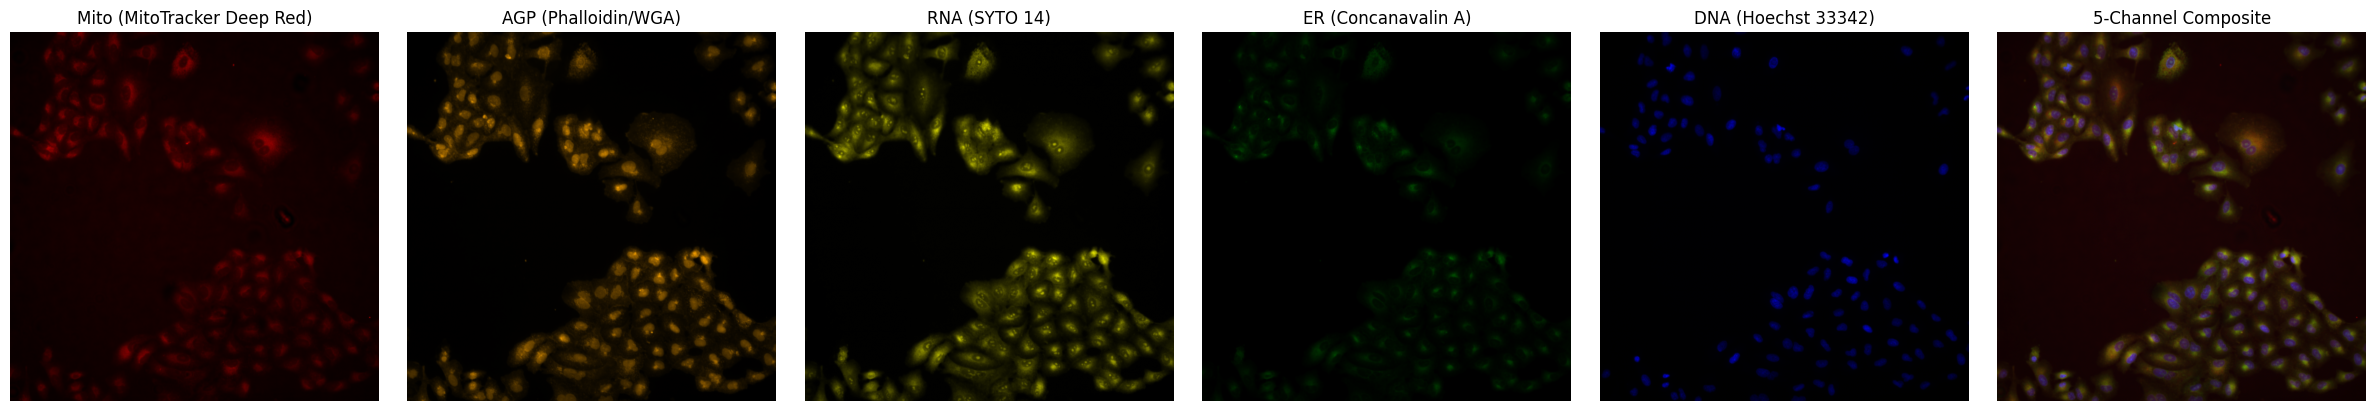

In [14]:
# make sure you have pip installed imagedocs first 

def display_all_channels_true_color(batch, plate, row, col, site):
    # Define all 5 fluorescent channels with their proper colors
    channels = {
        1: {"name": "Mito (MitoTracker Deep Red)", "color": "red"},
        2: {"name": "AGP (Phalloidin/WGA)", "color": "orange"},
        3: {"name": "RNA (SYTO 14)", "color": "yellow"},
        4: {"name": "ER (Concanavalin A)", "color": "green"},
        5: {"name": "DNA (Hoechst 33342)", "color": "blue"}
    }
    
    # Create a figure for channels
    fig, axes = plt.subplots(1, len(channels) + 1, figsize=(24, 4))
    
    # Store images for composite
    all_imgs = []
    
    # Display individual channels
    for i, (ch_num, ch_info) in enumerate(channels.items()):
        img = get_image(batch, plate, row, col, site, ch_num)
        if img is not None:
            # Normalize to 0-1 range for display
            img_norm = img.astype(float) / img.max()
            all_imgs.append(img_norm)
            
            # Create custom colormap for this channel
            cmap = mcolors.LinearSegmentedColormap.from_list(
                f"custom_{ch_info['color']}", 
                ["black", ch_info['color']]
            )
            axes[i].imshow(img_norm, cmap=cmap)
            axes[i].set_title(ch_info['name'])
            axes[i].axis('off')
    
    # Create colorful composite image
    if len(all_imgs) == 5:
        # Create multichannel composite
        composite = np.zeros((*all_imgs[0].shape, 3))
        
        # Add each channel with appropriate color weighting
        composite[..., 2] = all_imgs[4]  # DNA - blue
        composite[..., 1] = 0.7*all_imgs[3] + 0.3*all_imgs[2]  # ER (green) + RNA (yellow-green)
        composite[..., 0] = 0.7*all_imgs[0] + 0.3*all_imgs[1]  # Mito (red) + AGP (orange)
        
        # Display composite
        axes[5].imshow(composite)
        axes[5].set_title("5-Channel Composite")
        axes[5].axis('off')
    
    plt.tight_layout()
    plt.show()

# Display with all channels in true colors
display_all_channels_true_color(batch, plate, row, col, site)

This is showing just one field of view (site) from one well of one plate. The full dataset contains:

- 6 batches
- Multiple plates per batch (the first batch had at least 5 plates)
- 384 wells per plate (16 rows × 24 columns)
- ~9 sites per well (fields of view)
- 8 channels per site (5 fluorescent + 3 brightfield)

So this is one field of view out of potentially tens of thousands in the full dataset.


=== Batch: 2020_11_04_CPJUMP1 ===

--- Plate: BR00116991__2020-11-05T19_51_35-Measurement1 ---

Sample 1:
  Batch: 2020_11_04_CPJUMP1
  Plate: BR00116991__2020-11-05T19_51_35-Measurement1
  Well: A09
  Row: 1
  Column: 9
  Site: 6
  Image Path: r01c09f06p01-ch*sk1fk1fl1.tiff


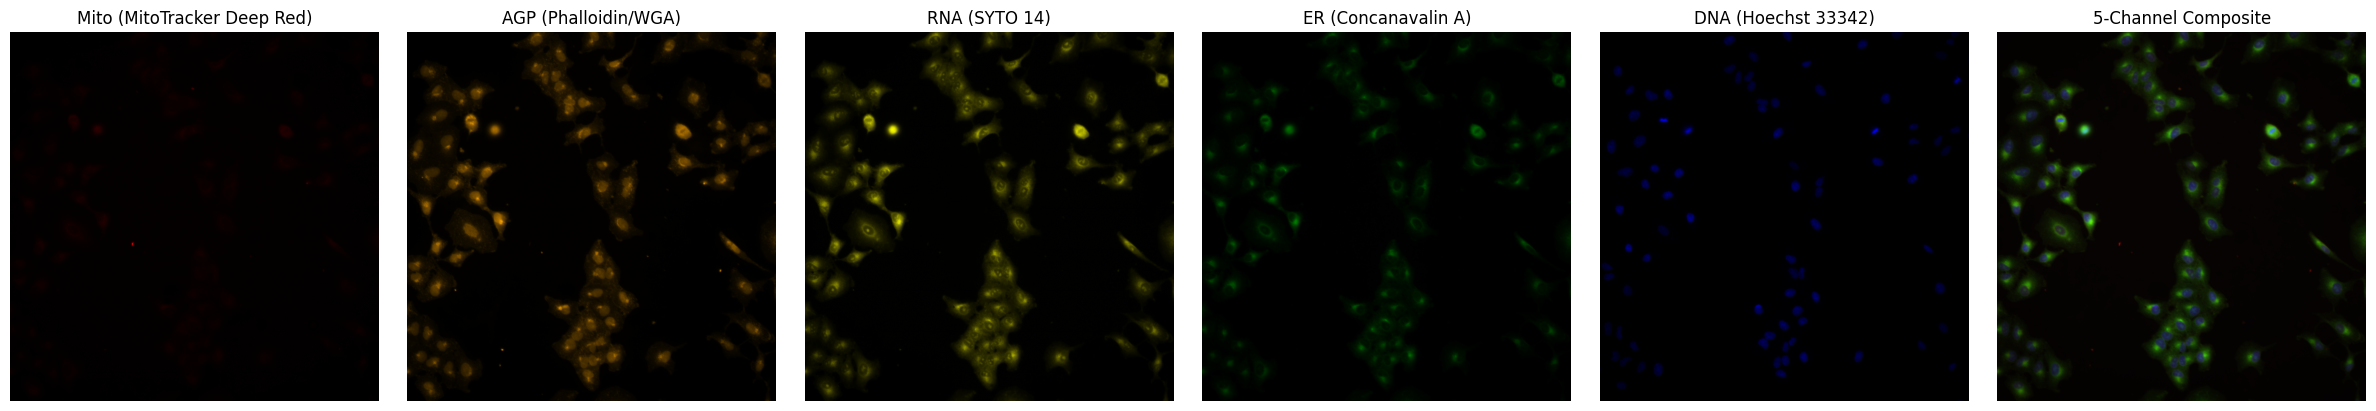


Sample 2:
  Batch: 2020_11_04_CPJUMP1
  Plate: BR00116991__2020-11-05T19_51_35-Measurement1
  Well: A10
  Row: 1
  Column: 10
  Site: 1
  Image Path: r01c10f01p01-ch*sk1fk1fl1.tiff


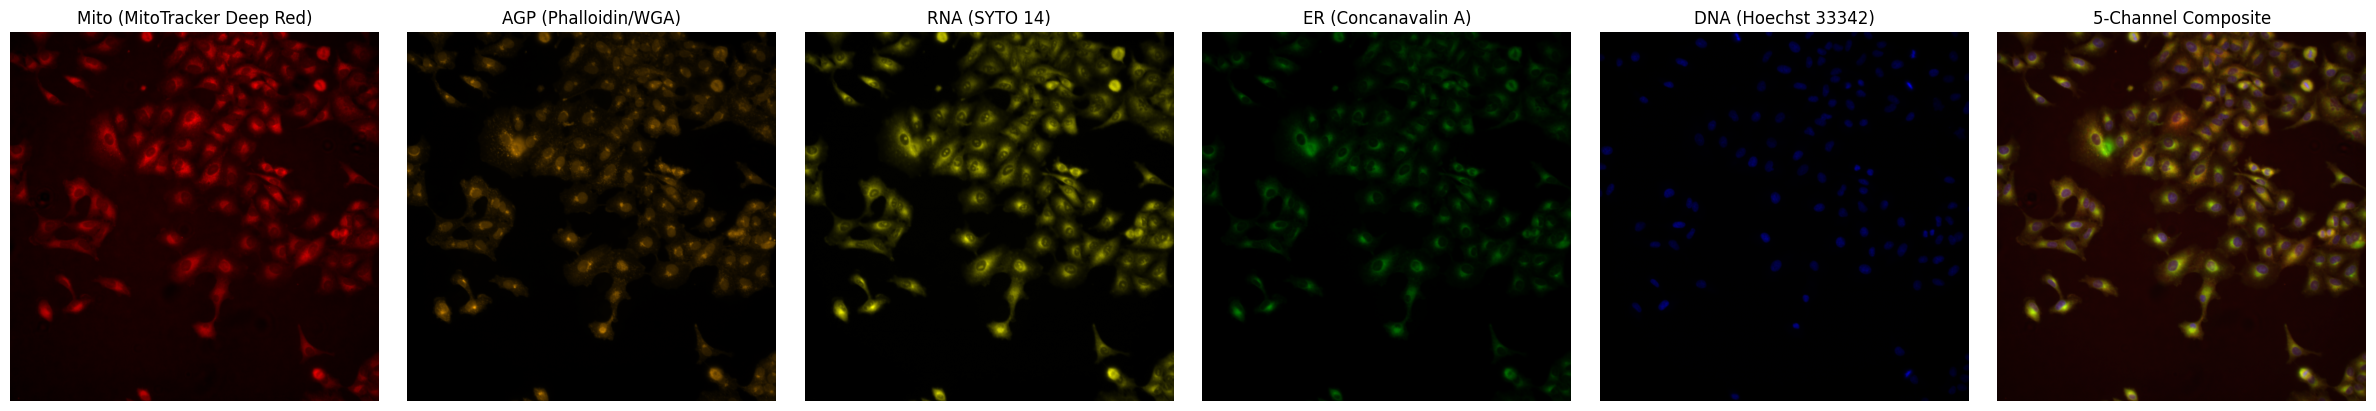


--- Plate: BR00116992__2020-11-05T21_31_31-Measurement1 ---

Sample 1:
  Batch: 2020_11_04_CPJUMP1
  Plate: BR00116992__2020-11-05T21_31_31-Measurement1
  Well: M06
  Row: 13
  Column: 6
  Site: 7
  Image Path: r13c06f07p01-ch*sk1fk1fl1.tiff


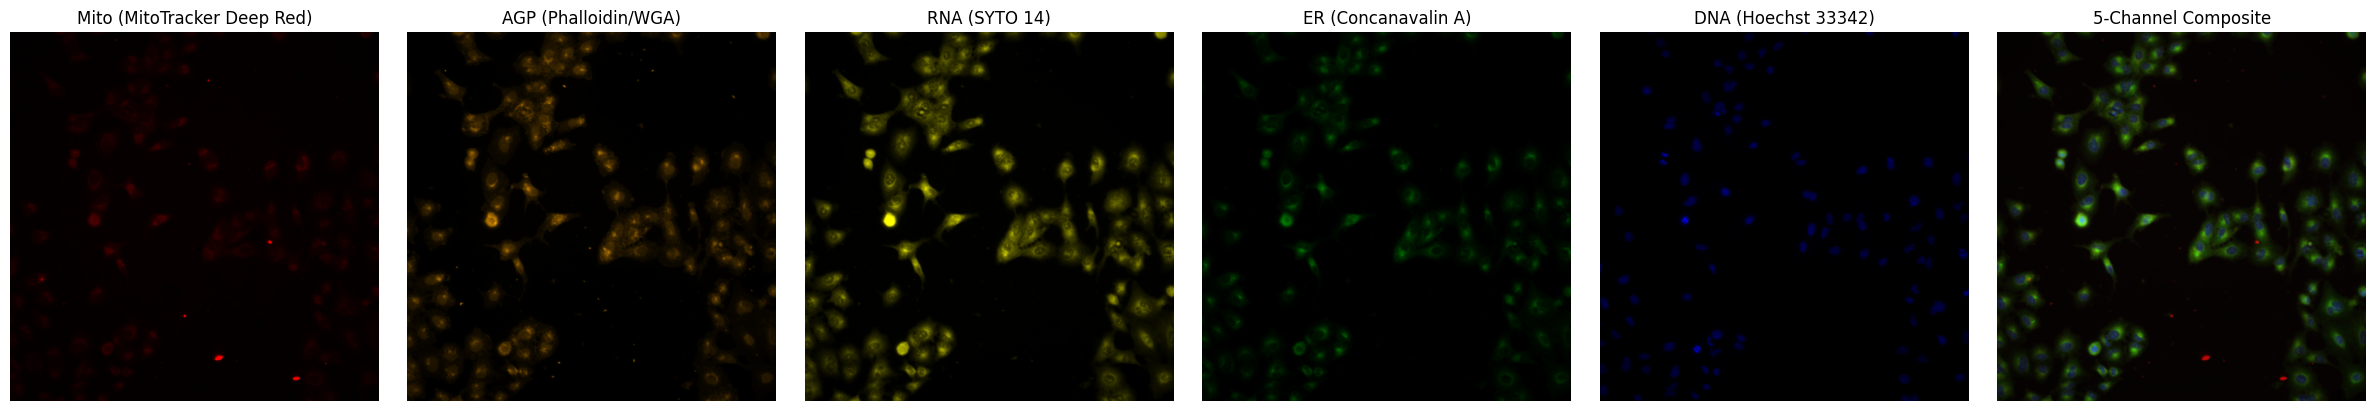


Sample 2:
  Batch: 2020_11_04_CPJUMP1
  Plate: BR00116992__2020-11-05T21_31_31-Measurement1
  Well: O18
  Row: 15
  Column: 18
  Site: 4
  Image Path: r15c18f04p01-ch*sk1fk1fl1.tiff


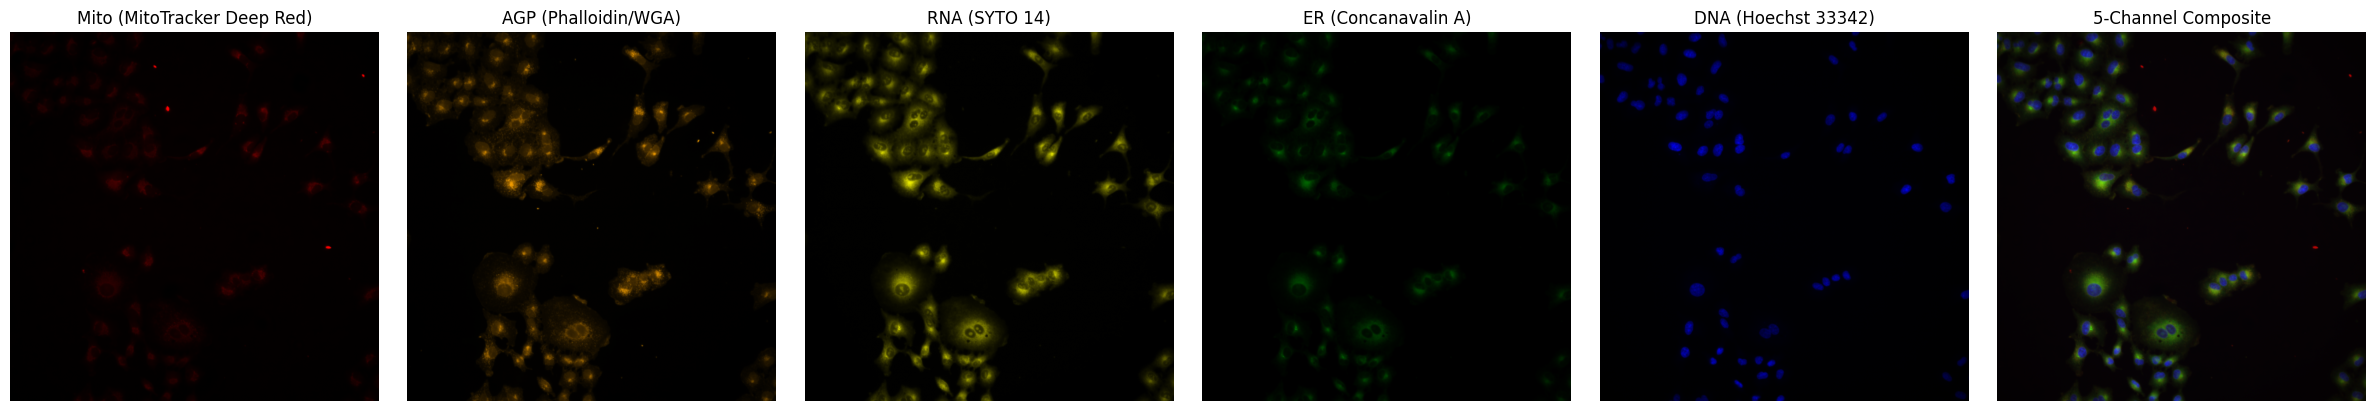


=== Batch: 2020_11_18_CPJUMP1_TimepointDay1 ===

--- Plate: BR00117006__2020-11-03T19_45_39-Measurement1 ---

Sample 1:
  Batch: 2020_11_18_CPJUMP1_TimepointDay1
  Plate: BR00117006__2020-11-03T19_45_39-Measurement1
  Well: E02
  Row: 5
  Column: 2
  Site: 3
  Image Path: r05c02f03p01-ch*sk1fk1fl1.tiff


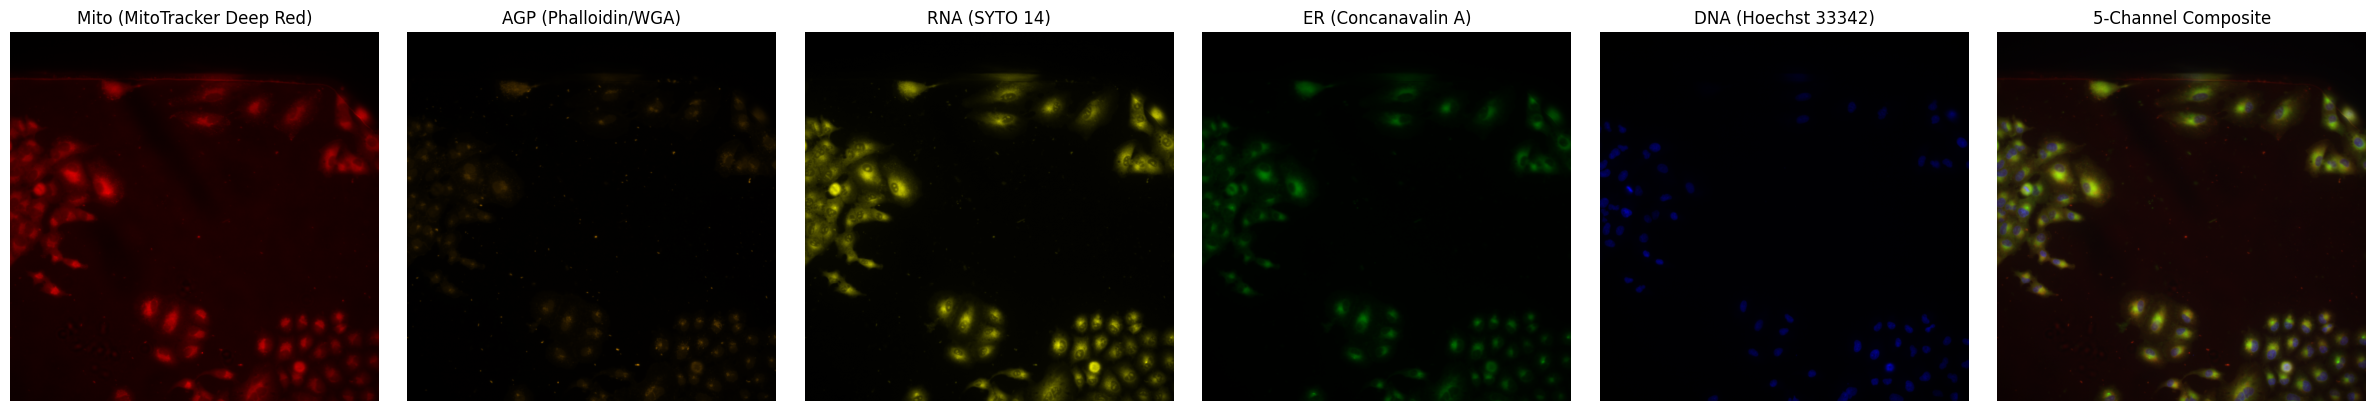


Sample 2:
  Batch: 2020_11_18_CPJUMP1_TimepointDay1
  Plate: BR00117006__2020-11-03T19_45_39-Measurement1
  Well: L06
  Row: 12
  Column: 6
  Site: 8
  Image Path: r12c06f08p01-ch*sk1fk1fl1.tiff
Error downloading image: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
Error downloading image: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
Error downloading image: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
Error downloading image: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
Error downloading image: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.


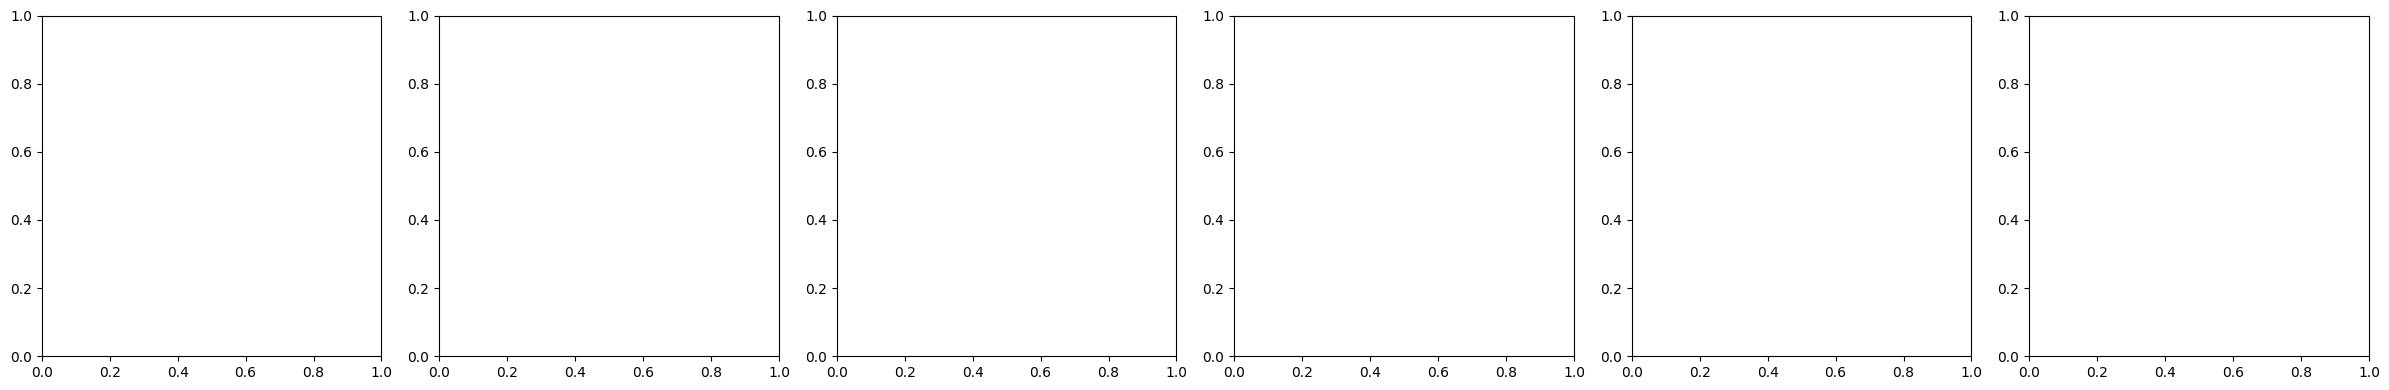


--- Plate: BR00117020__2020-11-05T17_27_45-Measurement1 ---

Sample 1:
  Batch: 2020_11_18_CPJUMP1_TimepointDay1
  Plate: BR00117020__2020-11-05T17_27_45-Measurement1
  Well: B06
  Row: 2
  Column: 6
  Site: 6
  Image Path: r02c06f06p01-ch*sk1fk1fl1.tiff


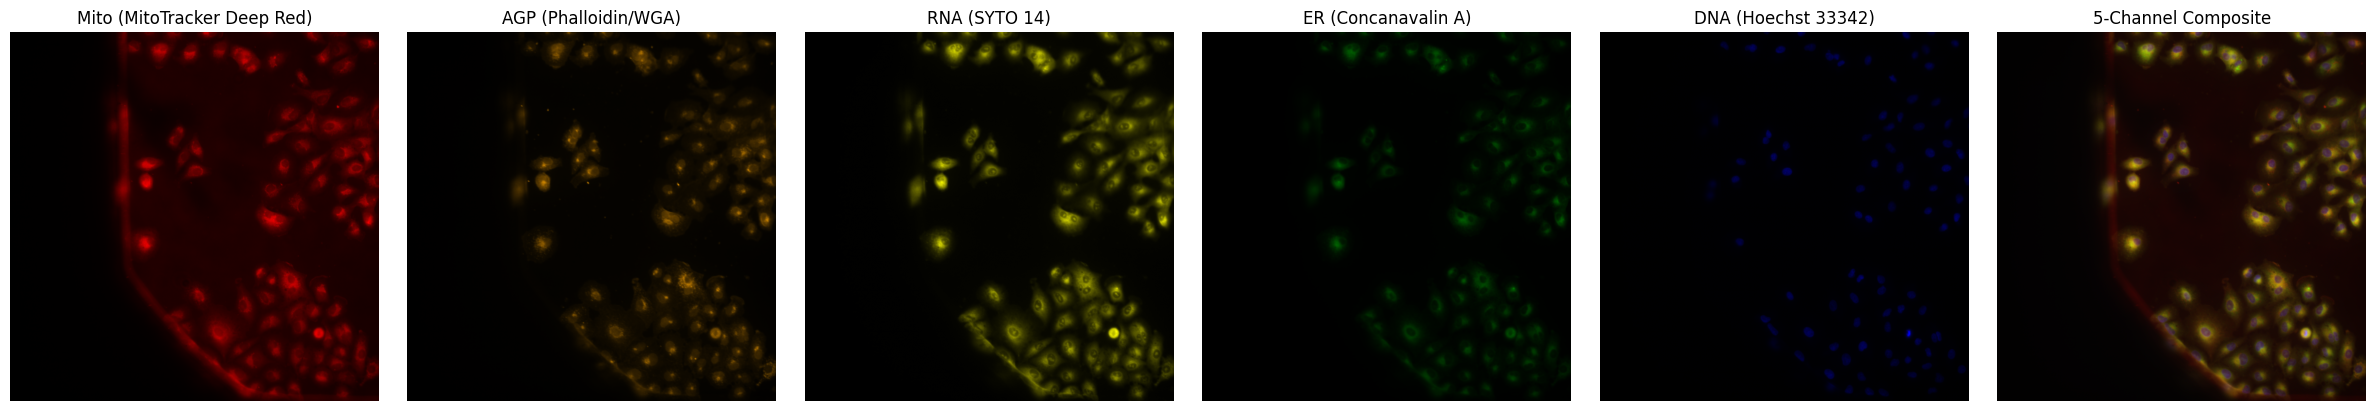


Sample 2:
  Batch: 2020_11_18_CPJUMP1_TimepointDay1
  Plate: BR00117020__2020-11-05T17_27_45-Measurement1
  Well: O12
  Row: 15
  Column: 12
  Site: 2
  Image Path: r15c12f02p01-ch*sk1fk1fl1.tiff
Error downloading image: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
Error downloading image: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
Error downloading image: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
Error downloading image: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
Error downloading image: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.


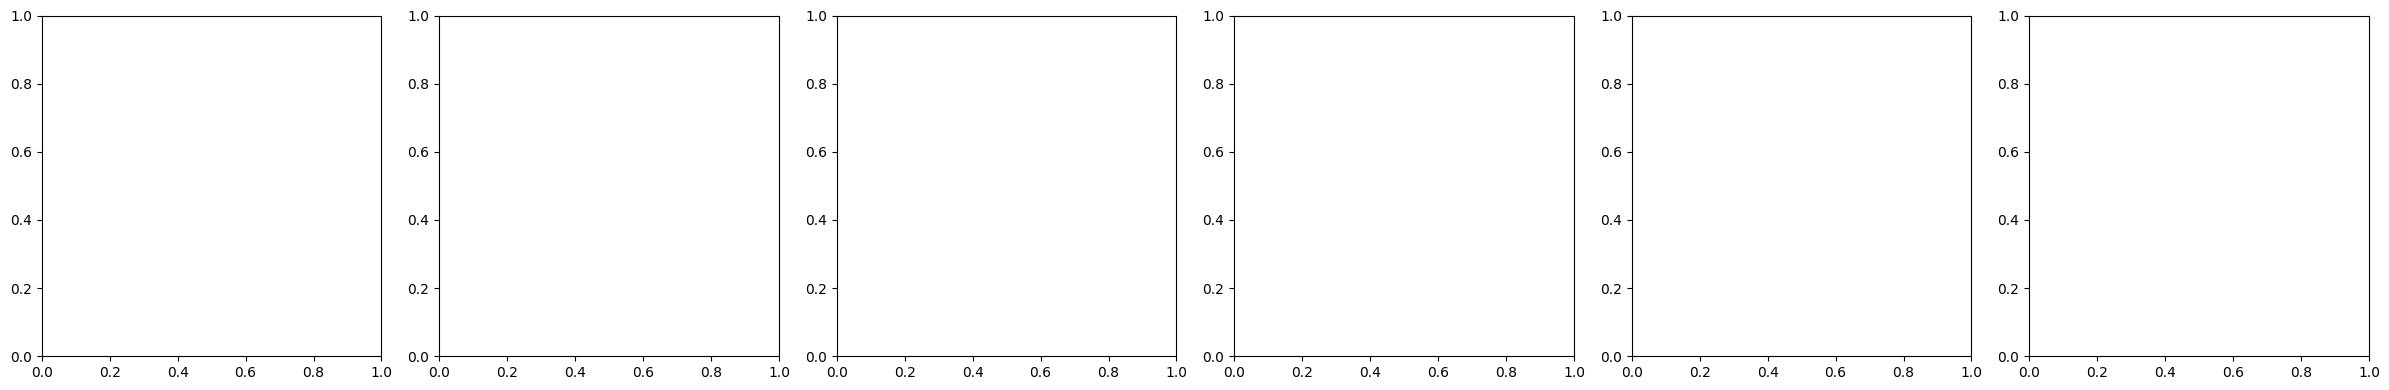


=== Batch: 2020_11_19_TimepointDay4 ===

--- Plate: BR00117006__2020-11-07T13_09_23-Measurement2 ---

Sample 1:
  Batch: 2020_11_19_TimepointDay4
  Plate: BR00117006__2020-11-07T13_09_23-Measurement2
  Well: I21
  Row: 9
  Column: 21
  Site: 2
  Image Path: r09c21f02p01-ch*sk1fk1fl1.tiff


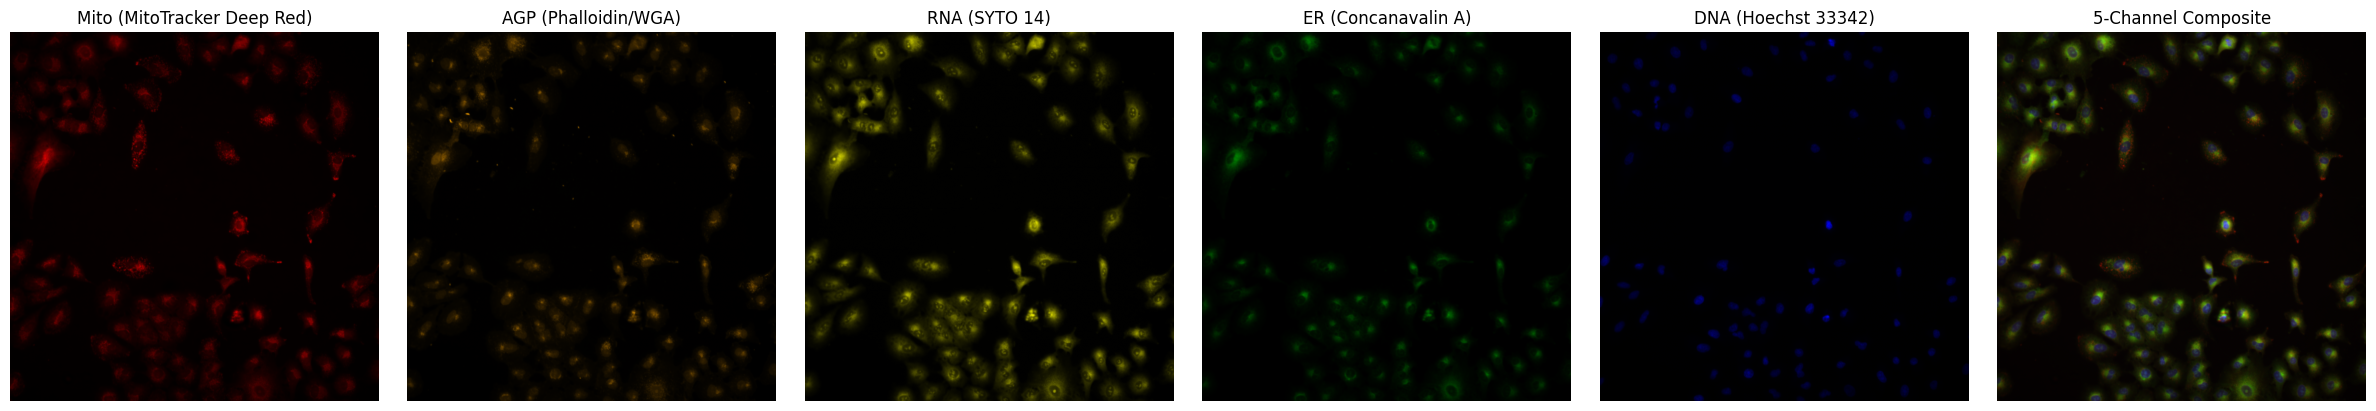


Sample 2:
  Batch: 2020_11_19_TimepointDay4
  Plate: BR00117006__2020-11-07T13_09_23-Measurement2
  Well: G23
  Row: 7
  Column: 23
  Site: 6
  Image Path: r07c23f06p01-ch*sk1fk1fl1.tiff
Error downloading image: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
Error downloading image: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
Error downloading image: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
Error downloading image: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
Error downloading image: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.


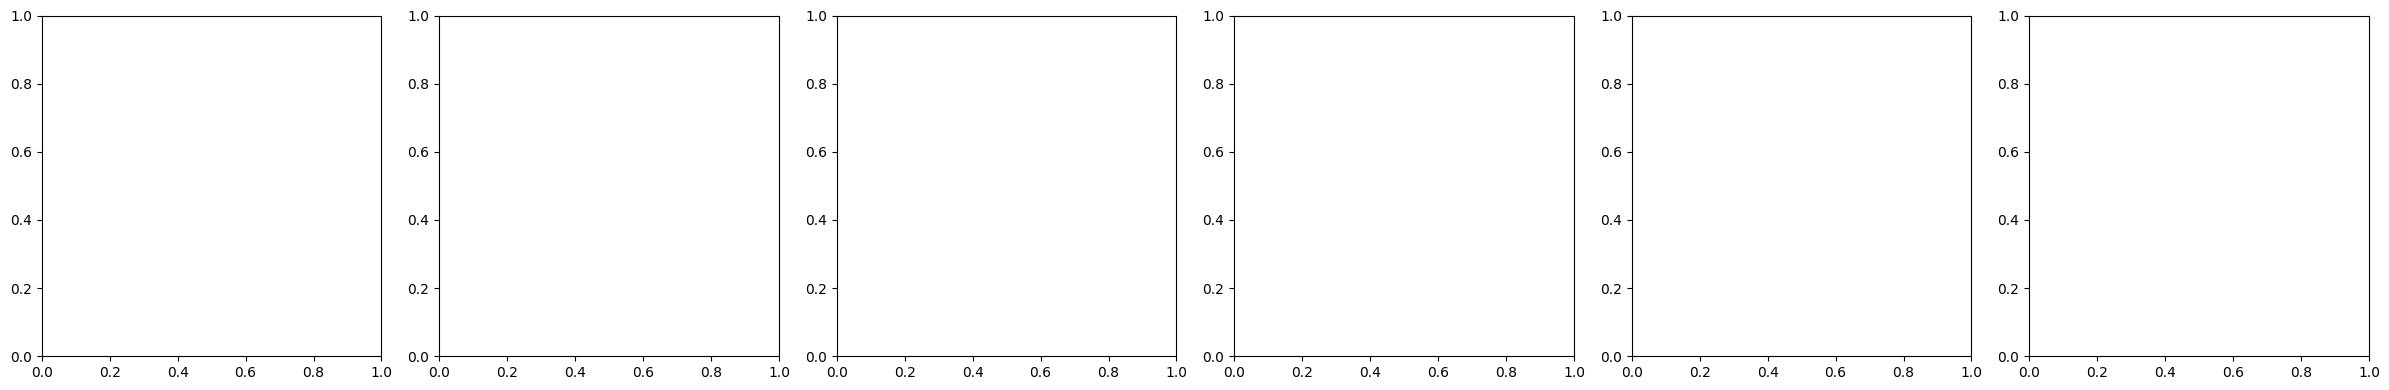


--- Plate: BR00117020__2020-11-10T19_28_53-Measurement2 ---

Sample 1:
  Batch: 2020_11_19_TimepointDay4
  Plate: BR00117020__2020-11-10T19_28_53-Measurement2
  Well: E05
  Row: 5
  Column: 5
  Site: 7
  Image Path: r05c05f07p01-ch*sk1fk1fl1.tiff


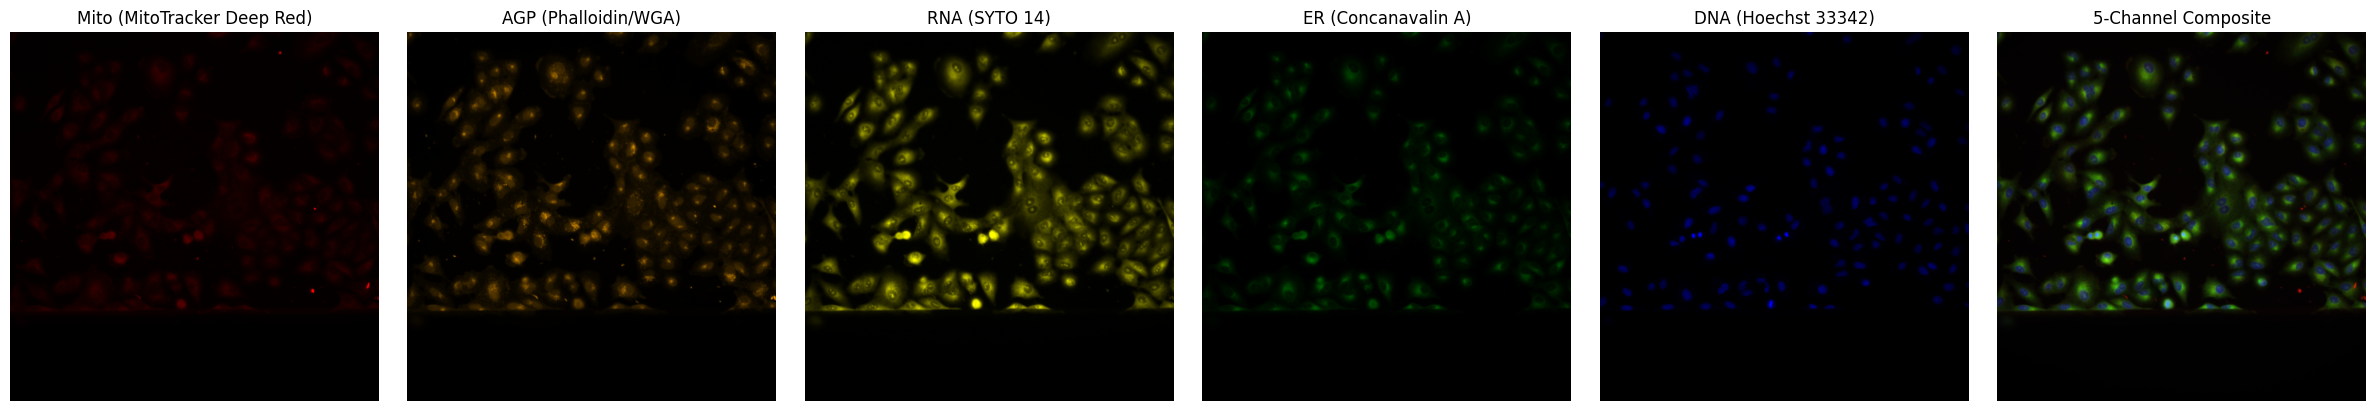


Sample 2:
  Batch: 2020_11_19_TimepointDay4
  Plate: BR00117020__2020-11-10T19_28_53-Measurement2
  Well: I17
  Row: 9
  Column: 17
  Site: 3
  Image Path: r09c17f03p01-ch*sk1fk1fl1.tiff


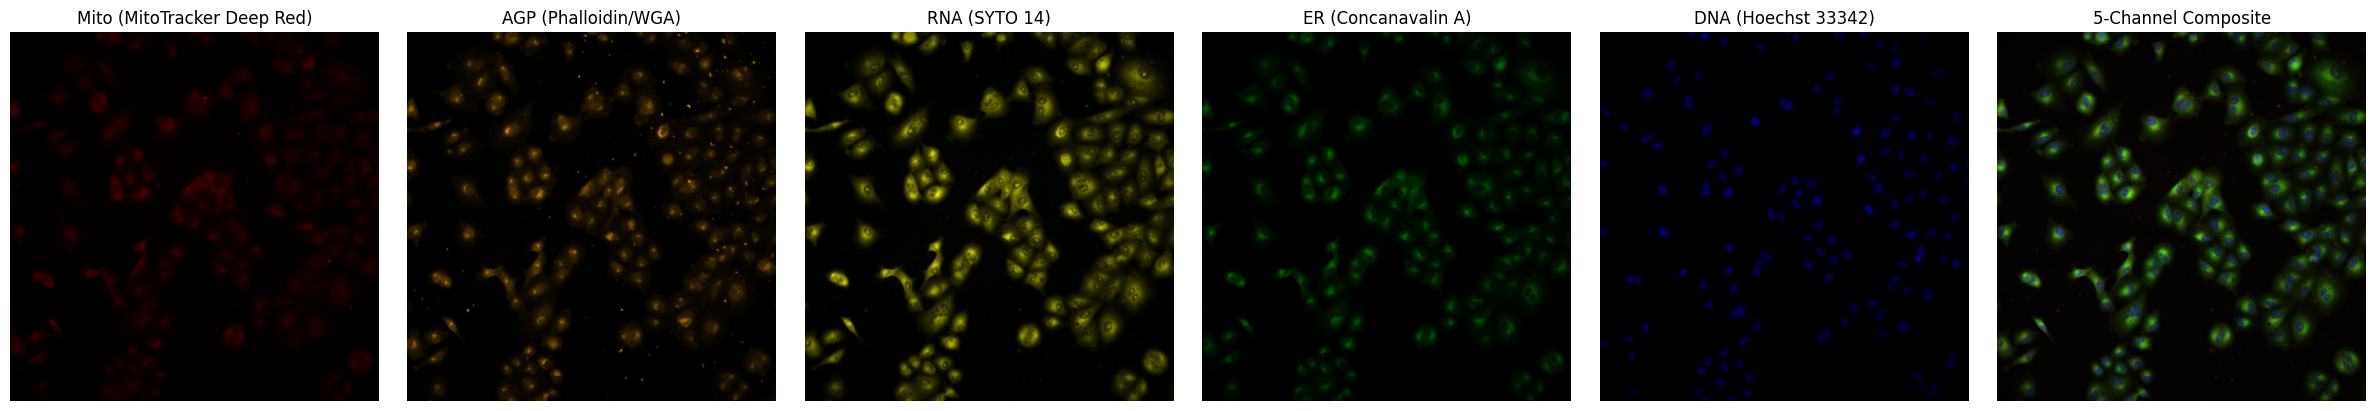

In [15]:
def explore_dataset_full(num_samples=2):
    """Display sample images from different batches with all channels and metadata"""
    # List of batches
    batches = [
        '2020_11_04_CPJUMP1',
        '2020_11_18_CPJUMP1_TimepointDay1',
        '2020_11_19_TimepointDay4',
        '2020_12_02_CPJUMP1_2WeeksTimePoint',
        '2020_12_07_CPJUMP1_4WeeksTimePoint',
        '2020_12_08_CPJUMP1_Bleaching'
    ]
    
    for batch_idx, batch in enumerate(batches[:3]):  # Limit to first 3 batches
        print(f"\n=== Batch: {batch} ===")
        
        # Get plates in batch
        batch_prefix = f"cpg0000-jump-pilot/source_4/images/{batch}/images/"
        response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=batch_prefix, Delimiter='/')
        plates = [common_prefix['Prefix'].split('/')[-2] for common_prefix in response.get('CommonPrefixes', [])]
        
        if not plates:
            print(f"No plates found in batch {batch}")
            continue
            
        # Show samples from different plates
        for plate in plates[:min(2, len(plates))]:  # Limit to max 2 plates per batch
            print(f"\n--- Plate: {plate} ---")
            
            # Pick random wells
            for sample_idx in range(num_samples):
                row = np.random.randint(1, 16)
                col = np.random.randint(1, 24)
                site = np.random.randint(1, 9)
                
                # Display metadata
                metadata = {
                    "Batch": batch,
                    "Plate": plate,
                    "Well": f"{chr(64+row)}{col:02d}",  # Convert row number to letter (A01, B02, etc.)
                    "Row": row,
                    "Column": col,
                    "Site": site,
                    "Image Path": f"r{row:02d}c{col:02d}f{site:02d}p01-ch*sk1fk1fl1.tiff"
                }
                
                print(f"\nSample {sample_idx+1}:")
                for key, value in metadata.items():
                    print(f"  {key}: {value}")
                
                # Define channels with their proper colors
                channels = {
                    1: {"name": "Mito (MitoTracker Deep Red)", "color": "red"},
                    2: {"name": "AGP (Phalloidin/WGA)", "color": "orange"},
                    3: {"name": "RNA (SYTO 14)", "color": "yellow"},
                    4: {"name": "ER (Concanavalin A)", "color": "green"},
                    5: {"name": "DNA (Hoechst 33342)", "color": "blue"}
                }
                
                # Create a figure for channels
                fig, axes = plt.subplots(1, len(channels) + 1, figsize=(24, 4))
                
                # Store images for composite
                all_imgs = []
                
                # Display individual channels
                for i, (ch_num, ch_info) in enumerate(channels.items()):
                    img = get_image(batch, plate, row, col, site, ch_num)
                    if img is not None:
                        # Normalize to 0-1 range for display
                        img_norm = img.astype(float) / img.max()
                        all_imgs.append(img_norm)
                        
                        # Create custom colormap for this channel
                        cmap = mcolors.LinearSegmentedColormap.from_list(
                            f"custom_{ch_info['color']}", 
                            ["black", ch_info['color']]
                        )
                        axes[i].imshow(img_norm, cmap=cmap)
                        axes[i].set_title(ch_info['name'])
                        axes[i].axis('off')
                
                # Create colorful composite image
                if len(all_imgs) == 5:
                    # Create multichannel composite
                    composite = np.zeros((*all_imgs[0].shape, 3))
                    
                    # Add each channel with appropriate color weighting
                    composite[..., 2] = all_imgs[4]  # DNA - blue
                    composite[..., 1] = 0.7*all_imgs[3] + 0.3*all_imgs[2]  # ER (green) + RNA (yellow-green)
                    composite[..., 0] = 0.7*all_imgs[0] + 0.3*all_imgs[1]  # Mito (red) + AGP (orange)
                    
                    # Display composite
                    axes[5].imshow(composite)
                    axes[5].set_title("5-Channel Composite")
                    axes[5].axis('off')
                
                plt.tight_layout()
                plt.show()

# Run the exploration
explore_dataset_full(num_samples=2)

In [16]:
def generate_batch_metadata():
    """Generate metadata table for all batches in the pilot experiment"""
    # List of batches
    batches = [
        '2020_11_04_CPJUMP1',
        '2020_11_18_CPJUMP1_TimepointDay1',
        '2020_11_19_TimepointDay4',
        '2020_12_02_CPJUMP1_2WeeksTimePoint',
        '2020_12_07_CPJUMP1_4WeeksTimePoint',
        '2020_12_08_CPJUMP1_Bleaching'
    ]
    
    metadata_table = []
    
    for batch in batches:
        print(f"Processing batch: {batch}")
        
        # Get plates in batch
        batch_prefix = f"cpg0000-jump-pilot/source_4/images/{batch}/images/"
        try:
            response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=batch_prefix, Delimiter='/')
            plates = [common_prefix['Prefix'].split('/')[-2] for common_prefix in response.get('CommonPrefixes', [])]
            
            for plate in plates:
                # Count image files in plate
                plate_prefix = f"{batch_prefix}{plate}/Images/"
                try:
                    paginator = s3.get_paginator('list_objects_v2')
                    
                    # Using a counter to avoid loading all file names into memory
                    total_images = 0
                    
                    # Count by pagination to handle large folders
                    for page in paginator.paginate(Bucket='cellpainting-gallery', Prefix=plate_prefix):
                        if 'Contents' in page:
                            # Only count TIFF files
                            total_images += sum(1 for item in page['Contents'] if item['Key'].endswith('.tiff'))
                    
                    # Sample an image to get dimensions
                    sample_prefix = f"{plate_prefix}r01c01f01p01-ch1sk1fk1fl1.tiff"
                    try:
                        response = s3.get_object(Bucket='cellpainting-gallery', Key=sample_prefix)
                        img = tifffile.imread(io.BytesIO(response['Body'].read()))
                        img_dimensions = f"{img.shape[0]} × {img.shape[1]}"
                    except:
                        img_dimensions = "Unknown"
                    
                    # Calculate other metadata
                    channels_per_site = 8  # 5 fluorescent + 3 brightfield
                    estimated_sites = total_images / channels_per_site
                    estimated_wells = None
                    
                    # Check if wells are complete
                    if 9 <= estimated_sites / 384 <= 10:  # ~9 sites per well, 384 wells per plate
                        estimated_wells = 384
                        sites_per_well = round(estimated_sites / 384, 1)
                    else:
                        # Try to estimate wells that have data
                        # This is an approximation for partially filled plates
                        sites_per_well = 9  # typical number
                        estimated_wells = round(estimated_sites / sites_per_well)
                    
                    # Add to metadata table
                    metadata_table.append({
                        'Batch': batch,
                        'Plate': plate,
                        'Total Images': total_images,
                        'Image Dimensions': img_dimensions,
                        'Channels': channels_per_site,
                        'Estimated Sites': int(estimated_sites),
                        'Estimated Wells with Data': estimated_wells,
                        'Sites per Well': sites_per_well
                    })
                    
                except Exception as e:
                    print(f"  Error counting images for plate {plate}: {e}")
                    metadata_table.append({
                        'Batch': batch,
                        'Plate': plate,
                        'Error': str(e)
                    })
            
        except Exception as e:
            print(f"Error listing plates for batch {batch}: {e}")
            metadata_table.append({
                'Batch': batch,
                'Error': str(e)
            })
    
    # Convert to DataFrame for display
    metadata_df = pd.DataFrame(metadata_table)
    
    # Display summary statistics
    if not metadata_df.empty:
        print("\n=== Summary Statistics ===")
        batch_summary = metadata_df.groupby('Batch').agg({
            'Plate': 'count',
            'Total Images': 'sum',
            'Estimated Sites': 'sum',
            'Estimated Wells with Data': 'sum'
        }).rename(columns={'Plate': 'Plate Count'})
        
        print("\nBatch-level Summary:")
        print(batch_summary)
        
        total_summary = {
            'Total Batches': len(batches),
            'Total Plates': metadata_df['Plate'].nunique(),
            'Total Images': metadata_df['Total Images'].sum(),
            'Total Estimated Sites': metadata_df['Estimated Sites'].sum(),
            'Total Estimated Wells': metadata_df['Estimated Wells with Data'].sum()
        }
        
        print("\nOverall Summary:")
        for key, value in total_summary.items():
            print(f"{key}: {value}")
    
    return metadata_df

# Generate and display metadata table
metadata_df = generate_batch_metadata()
metadata_df

Processing batch: 2020_11_04_CPJUMP1
Processing batch: 2020_11_18_CPJUMP1_TimepointDay1
Processing batch: 2020_11_19_TimepointDay4
Processing batch: 2020_12_02_CPJUMP1_2WeeksTimePoint
Processing batch: 2020_12_07_CPJUMP1_4WeeksTimePoint
Processing batch: 2020_12_08_CPJUMP1_Bleaching

=== Summary Statistics ===

Batch-level Summary:
                                    Plate Count  Total Images  \
Batch                                                           
2020_11_04_CPJUMP1                           51       1496064   
2020_11_18_CPJUMP1_TimepointDay1              8         98304   
2020_11_19_TimepointDay4                      8         98304   
2020_12_02_CPJUMP1_2WeeksTimePoint            8        221184   
2020_12_07_CPJUMP1_4WeeksTimePoint            8        221184   
2020_12_08_CPJUMP1_Bleaching                 24        589824   

                                    Estimated Sites  Estimated Wells with Data  
Batch                                                           

,Batch,Plate,Total Images,Image Dimensions,Channels,Estimated Sites,Estimated Wells with Data,Sites per Well
0,2020_11_04_CPJUMP1,BR00116991__2020-11-05T19_51_35-Measurement1,27648,1080 × 1080,8,3456,384,9.0
1,2020_11_04_CPJUMP1,BR00116992__2020-11-05T21_31_31-Measurement1,27648,1080 × 1080,8,3456,384,9.0
2,2020_11_04_CPJUMP1,BR00116993__2020-11-05T23_11_39-Measurement1,27648,1080 × 1080,8,3456,384,9.0
3,2020_11_04_CPJUMP1,BR00116994__2020-11-06T00_59_44-Measurement1,27648,1080 × 1080,8,3456,384,9.0
4,2020_11_04_CPJUMP1,BR00116995__2020-11-06T02_41_05-Measurement1,27648,1080 × 1080,8,3456,384,9.0
...,...,...,...,...,...,...,...,...
102,2020_12_08_CPJUMP1_Bleaching,BR00116994B__2020-11-17T19_27_41-Measurement1,27648,Unknown,8,3456,384,9.0
103,2020_12_08_CPJUMP1_Bleaching,BR00116994C__2020-11-17T19_27_41-Measurement1,27648,Unknown,8,3456,384,9.0
104,2020_12_08_CPJUMP1_Bleaching,BR00116994D__2020-11-17T19_27_41-Measurement1,27648,Unknown,8,3456,384,9.0
105,2020_12_08_CPJUMP1_Bleaching,BR00116994E__2020-11-17T19_27_41-Measurement1,27648,Unknown,8,3456,384,9.0


In [8]:
import boto3
from botocore.config import Config

# S3 client setup for accessing public data
from botocore import UNSIGNED
s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))
S3_BUCKET = "cellpainting-gallery"
batch = "2020_11_04_CPJUMP1"

def explore_batch_structure(batch_name):
    """Explore the directory structure of a specific batch"""
    
    # Base prefix for the batch
    base_prefix = f"cpg0000-jump-pilot/source_4/"
    
    print(f"Exploring batch: {batch_name}")
    print("=" * 50)
    
    # Check main subdirectories in source_4
    response = s3.list_objects_v2(
        Bucket=S3_BUCKET,
        Prefix=base_prefix,
        Delimiter='/'
    )
    
    main_dirs = [prefix['Prefix'].split('/')[-2] for prefix in response.get('CommonPrefixes', [])]
    print(f"Main directories in source_4:")
    for dir_name in main_dirs:
        print(f"  - {dir_name}")
    
    # Explore each main directory for this batch
    for main_dir in main_dirs:
        print(f"\n--- Checking {main_dir} ---")
        dir_prefix = f"{base_prefix}{main_dir}/"
        
        # Check if batch exists in this directory
        batch_prefix = f"{dir_prefix}{batch_name}/"
        
        try:
            response = s3.list_objects_v2(
                Bucket=S3_BUCKET,
                Prefix=batch_prefix,
                Delimiter='/',
                MaxKeys=1
            )
            
            if response.get('CommonPrefixes') or response.get('Contents'):
                print(f"  ✓ {batch_name} found in {main_dir}")
                
                # List subdirectories in this batch location
                subdirs = [prefix['Prefix'].split('/')[-2] for prefix in response.get('CommonPrefixes', [])]
                if subdirs:
                    print(f"    Subdirectories:")
                    for subdir in subdirs:
                        print(f"      - {subdir}")
                
                # List files if any
                files = [obj['Key'].split('/')[-1] for obj in response.get('Contents', []) if obj['Key'].endswith('/') == False]
                if files:
                    print(f"    Files (first 5):")
                    for file in files[:5]:
                        print(f"      - {file}")
                    if len(files) > 5:
                        print(f"      ... and {len(files) - 5} more files")
            else:
                print(f"  ✗ {batch_name} not found in {main_dir}")
                
        except Exception as e:
            print(f"  ✗ Error accessing {main_dir}: {e}")

def explore_specific_path(path):
    """Explore a specific path in detail"""
    print(f"\nDetailed exploration of: {path}")
    print("-" * 50)
    
    try:
        response = s3.list_objects_v2(
            Bucket=S3_BUCKET,
            Prefix=path,
            Delimiter='/',
            MaxKeys=20
        )
        
        # List subdirectories
        subdirs = [prefix['Prefix'].split('/')[-2] for prefix in response.get('CommonPrefixes', [])]
        if subdirs:
            print(f"Subdirectories:")
            for subdir in subdirs:
                print(f"  - {subdir}")
        
        # List files
        files = [obj['Key'].split('/')[-1] for obj in response.get('Contents', []) if not obj['Key'].endswith('/')]
        if files:
            print(f"Files:")
            for file in files:
                print(f"  - {file}")
                
    except Exception as e:
        print(f"Error: {e}")

# Run the exploration
explore_batch_structure(batch)

# You can also explore specific paths of interest
print("\n" + "=" * 70)
print("EXPLORING SPECIFIC PATHS")
print("=" * 70)

# Explore images directory
explore_specific_path(f"cpg0000-jump-pilot/source_4/images/{batch}/")

# Explore illum directory specifically
explore_specific_path(f"cpg0000-jump-pilot/source_4/images/{batch}/illum/")

# Explore a specific plate's illum files
explore_specific_path(f"cpg0000-jump-pilot/source_4/images/{batch}/illum/BR00116991/")

# Explore backend directory  
explore_specific_path(f"cpg0000-jump-pilot/source_4/workspace/backend/{batch}/")

Exploring batch: 2020_11_04_CPJUMP1
Main directories in source_4:
  - images
  - workspace

--- Checking images ---
  ✓ 2020_11_04_CPJUMP1 found in images
    Subdirectories:
      - illum

--- Checking workspace ---
  ✗ 2020_11_04_CPJUMP1 not found in workspace

EXPLORING SPECIFIC PATHS

Detailed exploration of: cpg0000-jump-pilot/source_4/images/2020_11_04_CPJUMP1/
--------------------------------------------------
Subdirectories:
  - illum
  - images

Detailed exploration of: cpg0000-jump-pilot/source_4/images/2020_11_04_CPJUMP1/illum/
--------------------------------------------------
Subdirectories:
  - BR00116991
  - BR00116992
  - BR00116993
  - BR00116994
  - BR00116995
  - BR00116996
  - BR00116997
  - BR00116998
  - BR00116999
  - BR00117000
  - BR00117001
  - BR00117002
  - BR00117003
  - BR00117004
  - BR00117005
  - BR00117006
  - BR00117008
  - BR00117009
  - BR00117010
  - BR00117011

Detailed exploration of: cpg0000-jump-pilot/source_4/images/2020_11_04_CPJUMP1/illum/BR

Download the necessary illum batch folders

In [9]:
import boto3
import os
from botocore import UNSIGNED
from botocore.config import Config

# S3 client setup
s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))
S3_BUCKET = "cellpainting-gallery"

# Test plates from your metadata
test_plates = [
    "BR00118045",
    "BR00118046", 
    "BR00118047",
    "BR00118048",
    "BR00118049",
    "BR00118050"
]

batch = "2020_11_04_CPJUMP1"
local_dir = "illumination_files"

# Create local directory
os.makedirs(local_dir, exist_ok=True)

def download_illum_files_for_plate(plate_id):
    """Download illumination files for a specific plate"""
    plate_prefix = f"cpg0000-jump-pilot/source_4/images/{batch}/illum/{plate_id}/"
    
    # Create plate directory
    plate_dir = os.path.join(local_dir, plate_id)
    os.makedirs(plate_dir, exist_ok=True)
    
    # List files in the plate directory
    response = s3.list_objects_v2(Bucket=S3_BUCKET, Prefix=plate_prefix)
    
    if 'Contents' not in response:
        print(f"No files found for plate {plate_id}")
        return
    
    files = [obj['Key'] for obj in response['Contents']]
    print(f"Downloading {len(files)} files for plate {plate_id}...")
    
    for file_key in files:
        filename = file_key.split('/')[-1]
        local_path = os.path.join(plate_dir, filename)
        
        try:
            s3.download_file(S3_BUCKET, file_key, local_path)
            print(f"  ✓ {filename}")
        except Exception as e:
            print(f"  ✗ Failed to download {filename}: {e}")

# Download illumination files for all test plates
print(f"Downloading illumination files for {len(test_plates)} test plates...")
print("=" * 60)

for plate in test_plates:
    download_illum_files_for_plate(plate)
    print()

print(f"Download complete! Files saved to: {local_dir}/")
print(f"Directory structure:")
for plate in test_plates:
    plate_dir = os.path.join(local_dir, plate)
    if os.path.exists(plate_dir):
        file_count = len(os.listdir(plate_dir))
        print(f"  {plate}/: {file_count} files")

  ✓ BR00118045_IllumAGP.npy
  ✓ BR00118045_IllumBrightfield.npy
  ✓ BR00118045_IllumDNA.npy
  ✓ BR00118045_IllumER.npy
  ✓ BR00118045_IllumHighZBF.npy
  ✓ BR00118045_IllumLowZBF.npy
  ✓ BR00118045_IllumMito.npy
  ✓ BR00118045_IllumRNA.npy

  ✓ BR00118046_IllumAGP.npy
  ✓ BR00118046_IllumBrightfield.npy
  ✓ BR00118046_IllumDNA.npy
  ✓ BR00118046_IllumER.npy
  ✓ BR00118046_IllumHighZBF.npy
  ✓ BR00118046_IllumLowZBF.npy
  ✓ BR00118046_IllumMito.npy
  ✓ BR00118046_IllumRNA.npy

  ✓ BR00118047_IllumAGP.npy
  ✓ BR00118047_IllumBrightfield.npy
  ✓ BR00118047_IllumDNA.npy
  ✓ BR00118047_IllumER.npy
  ✓ BR00118047_IllumHighZBF.npy
  ✓ BR00118047_IllumLowZBF.npy
  ✓ BR00118047_IllumMito.npy
  ✓ BR00118047_IllumRNA.npy

  ✓ BR00118048_IllumAGP.npy
  ✓ BR00118048_IllumBrightfield.npy
  ✓ BR00118048_IllumDNA.npy
  ✓ BR00118048_IllumER.npy
  ✓ BR00118048_IllumHighZBF.npy
  ✓ BR00118048_IllumLowZBF.npy
  ✓ BR00118048_IllumMito.npy
  ✓ BR00118048_IllumRNA.npy

  ✓ BR00118049_IllumAGP.npy
  ✓ BR001180

Let's check if the 3 brightfield channels are also in pg0000-jump-pilot/source_4/images/ as well .....

In [2]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import re

# Setup S3 client
s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))

# Check what's in the images folder
prefix = 'cpg0000-jump-pilot/source_4/images/'
response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=prefix, Delimiter='/')

print("Folders in cpg0000-jump-pilot/source_4/images/:")
batches = []
for common_prefix in response.get('CommonPrefixes', []):
    batch_name = common_prefix['Prefix'].split('/')[-2]
    batches.append(batch_name)
    print(f"  - {batch_name}")

# Pick first batch to examine further
if batches:
    batch = batches[0]
    print(f"\nExamining batch: {batch}")
    
    # Check what's inside this batch
    batch_prefix = f"{prefix}{batch}/"
    response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=batch_prefix, Delimiter='/')
    
    print(f"Contents of {batch}:")
    for common_prefix in response.get('CommonPrefixes', []):
        folder_name = common_prefix['Prefix'].split('/')[-2]
        print(f"  - {folder_name}")
    
    # Check the images subfolder
    images_prefix = f"{batch_prefix}images/"
    response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=images_prefix, Delimiter='/')
    
    plates = []
    print(f"\nPlates in {batch}/images/:")
    for common_prefix in response.get('CommonPrefixes', []):
        plate_name = common_prefix['Prefix'].split('/')[-2]
        plates.append(plate_name)
        print(f"  - {plate_name}")
    
    # Check actual image files in first plate
    if plates:
        plate = plates[0]
        print(f"\nChecking image files in plate: {plate}")
        
        plate_images_prefix = f"{images_prefix}{plate}/Images/"
        response = s3.list_objects_v2(Bucket='cellpainting-gallery', 
                                    Prefix=plate_images_prefix, MaxKeys=20)
        
        print(f"Sample image files:")
        channels_found = set()
        for item in response.get('Contents', []):
            filename = item['Key'].split('/')[-1]
            if filename.endswith('.tiff'):
                print(f"  - {filename}")
                # Extract channel number
                match = re.search(r'-ch(\d+)sk1fk1fl1\.tiff$', filename)
                if match:
                    channels_found.add(int(match.group(1)))
        
        print(f"\nChannels detected: {sorted(channels_found)}")
        print(f"Total channels: {len(channels_found)}")
        
        if 6 in channels_found and 7 in channels_found and 8 in channels_found:
            print("✅ Channels 6, 7, 8 found! (OrigBrightfield, OrigHighZBF, OrigLowZBF)")
        else:
            missing = []
            for ch in [6, 7, 8]:
                if ch not in channels_found:
                    missing.append(ch)
            print(f"❌ Missing channels: {missing}")

Folders in cpg0000-jump-pilot/source_4/images/:
  - 2020_11_04_CPJUMP1
  - 2020_11_18_CPJUMP1_TimepointDay1
  - 2020_11_19_TimepointDay4
  - 2020_12_02_CPJUMP1_2WeeksTimePoint
  - 2020_12_07_CPJUMP1_4WeeksTimePoint
  - 2020_12_08_CPJUMP1_Bleaching

Examining batch: 2020_11_04_CPJUMP1
Contents of 2020_11_04_CPJUMP1:
  - illum
  - images

Plates in 2020_11_04_CPJUMP1/images/:
  - BR00116991__2020-11-05T19_51_35-Measurement1
  - BR00116992__2020-11-05T21_31_31-Measurement1
  - BR00116993__2020-11-05T23_11_39-Measurement1
  - BR00116994__2020-11-06T00_59_44-Measurement1
  - BR00116995__2020-11-06T02_41_05-Measurement1
  - BR00116996__2020-11-09T15_32_10-Measurement3
  - BR00116997__2020-11-06T09_19_16-Measurement1
  - BR00116998__2020-11-06T20_06_24-Measurement1
  - BR00116999__2020-11-06T21_45_58-Measurement1
  - BR00117000__2020-11-03T07_28_24-Measurement1
  - BR00117001__2020-11-03T09_07_42-Measurement1
  - BR00117002__2020-11-05T00_04_13-Measurement1
  - BR00117003__2020-11-05T05_07_49

In [3]:
# Check for Index.idx.xml files in the plate structure
plate = "BR00116991__2020-11-05T19_51_35-Measurement1"
batch = "2020_11_04_CPJUMP1"

plate_prefix = f"cpg0000-jump-pilot/source_4/images/{batch}/images/{plate}/"
response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=plate_prefix, MaxKeys=50)

print(f"Files in plate {plate}:")
for item in response.get('Contents', []):
    filename = item['Key'].split('/')[-1]
    print(f"  - {filename}")
    
# Also check subfolders
response = s3.list_objects_v2(Bucket='cellpainting-gallery', Prefix=plate_prefix, Delimiter='/')
print(f"\nSubfolders in plate:")
for common_prefix in response.get('CommonPrefixes', []):
    folder_name = common_prefix['Prefix'].split('/')[-2]
    print(f"  - {folder_name}")

Files in plate BR00116991__2020-11-05T19_51_35-Measurement1:
  - Unnamed.xml
  - FFC_Profile_Measurement 1.xml
  - Index.idx.xml
  - r01c01f01p01-ch1sk1fk1fl1.tiff
  - r01c01f01p01-ch2sk1fk1fl1.tiff
  - r01c01f01p01-ch3sk1fk1fl1.tiff
  - r01c01f01p01-ch4sk1fk1fl1.tiff
  - r01c01f01p01-ch5sk1fk1fl1.tiff
  - r01c01f01p01-ch6sk1fk1fl1.tiff
  - r01c01f01p01-ch7sk1fk1fl1.tiff
  - r01c01f01p01-ch8sk1fk1fl1.tiff
  - r01c01f02p01-ch1sk1fk1fl1.tiff
  - r01c01f02p01-ch2sk1fk1fl1.tiff
  - r01c01f02p01-ch3sk1fk1fl1.tiff
  - r01c01f02p01-ch4sk1fk1fl1.tiff
  - r01c01f02p01-ch5sk1fk1fl1.tiff
  - r01c01f02p01-ch6sk1fk1fl1.tiff
  - r01c01f02p01-ch7sk1fk1fl1.tiff
  - r01c01f02p01-ch8sk1fk1fl1.tiff
  - r01c01f03p01-ch1sk1fk1fl1.tiff
  - r01c01f03p01-ch2sk1fk1fl1.tiff
  - r01c01f03p01-ch3sk1fk1fl1.tiff
  - r01c01f03p01-ch4sk1fk1fl1.tiff
  - r01c01f03p01-ch5sk1fk1fl1.tiff
  - r01c01f03p01-ch6sk1fk1fl1.tiff
  - r01c01f03p01-ch7sk1fk1fl1.tiff
  - r01c01f03p01-ch8sk1fk1fl1.tiff
  - r01c01f04p01-ch1sk1fk1fl1.t

In [9]:
import boto3
import pandas as pd
import os
from botocore import UNSIGNED
from botocore.config import Config

def well_to_row_col(well):
    """Convert well position (e.g., 'A01') to row and column numbers"""
    row = ord(well[0]) - ord('A') + 1  # A=1, B=2, etc.
    col = int(well[1:])  # Extract numeric part
    return row, col

def download_brightfield_channels_corrected(metadata_csv_path, output_dir="./brightfield_images"):
    """
    Download brightfield channels using corrected path structure
    """
    test_metadata = pd.read_csv(metadata_csv_path)
    s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))
    
    brightfield_channels = {6: "OrigBrightfield", 7: "OrigHighZBF", 8: "OrigLowZBF"}
    os.makedirs(output_dir, exist_ok=True)
    
    successful_downloads = 0
    
    for idx, row in test_metadata.iterrows():
        batch = row['batch']
        plate = row['plate']
        well = row['well']
        site = row['site']
        test_index = row['test_index']
        
        # Convert well to coordinates
        row_num, col_num = ord(well[0]) - ord('A') + 1, int(well[1:])
        row_str = f"r{row_num:02d}"
        col_str = f"c{col_num:02d}"
        site_str = f"f{site:02d}"
        
        for channel_num, channel_name in brightfield_channels.items():
            # CORRECTED: Include Images/ subdirectory
            filename = f"{row_str}{col_str}{site_str}p01-ch{channel_num}sk1fk1fl1.tiff"
            s3_key = f"cpg0000-jump-pilot/source_4/images/{batch}/images/{plate}/Images/{filename}"
            
            local_filename = f"test{test_index:03d}_{channel_name}_{plate}_{well}_site{site}.tiff"
            local_path = os.path.join(output_dir, local_filename)
            
            try:
                s3.download_file('cellpainting-gallery', s3_key, local_path)
                print(f"✅ Downloaded {channel_name} for test {test_index}")
                successful_downloads += 1
            except Exception as e:
                print(f"❌ Failed {channel_name} for test {test_index}: {e}")
    
    return successful_downloads

# Run the download function
if __name__ == "__main__":
    metadata_file = "test_images_metadata.csv"
    
    if os.path.exists(metadata_file):
        print("Starting brightfield channel download for test images...")
        success_count, total_count = download_brightfield_channels_corrected(metadata_file)
        
        if success_count == total_count:
            print("\\n🎉 All brightfield channels downloaded successfully!")
            print("You now have all 8 channels needed for CellProfiler.")
        else:
            print(f"\\n⚠️  Downloaded {success_count}/{total_count} files.")
            print("Some files may be missing from the S3 bucket.")
            
    else:
        print(f"❌ Could not find {metadata_file}")
        print("Make sure the test_images_metadata.csv file is in the current directory")

Starting brightfield channel download for test images...
✅ Downloaded OrigBrightfield for test 0
✅ Downloaded OrigHighZBF for test 0
✅ Downloaded OrigLowZBF for test 0
✅ Downloaded OrigBrightfield for test 1
✅ Downloaded OrigHighZBF for test 1
✅ Downloaded OrigLowZBF for test 1
✅ Downloaded OrigBrightfield for test 2
✅ Downloaded OrigHighZBF for test 2
✅ Downloaded OrigLowZBF for test 2
✅ Downloaded OrigBrightfield for test 3
✅ Downloaded OrigHighZBF for test 3
✅ Downloaded OrigLowZBF for test 3
✅ Downloaded OrigBrightfield for test 4
✅ Downloaded OrigHighZBF for test 4
✅ Downloaded OrigLowZBF for test 4
✅ Downloaded OrigBrightfield for test 5
✅ Downloaded OrigHighZBF for test 5
✅ Downloaded OrigLowZBF for test 5
✅ Downloaded OrigBrightfield for test 6
✅ Downloaded OrigHighZBF for test 6
✅ Downloaded OrigLowZBF for test 6
✅ Downloaded OrigBrightfield for test 7
✅ Downloaded OrigHighZBF for test 7
✅ Downloaded OrigLowZBF for test 7
✅ Downloaded OrigBrightfield for test 8
✅ Downloaded Or

TypeError: cannot unpack non-iterable int object

In [6]:
import boto3
import pandas as pd
from botocore import UNSIGNED
from botocore.config import Config

def diagnose_file_structure_issue():
    """
    Investigate why the brightfield channel files are not found
    """
    s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))
    
    # Load test metadata to get the problematic plates
    test_metadata = pd.read_csv("test_images_metadata.csv")
    
    # Get unique plates from test data
    unique_plates = test_metadata[['batch', 'plate']].drop_duplicates()
    print(f"Investigating {len(unique_plates)} unique plates from test data...")
    
    for idx, row in unique_plates.head(3).iterrows():  # Check first 3 plates
        batch = row['batch']
        plate = row['plate']
        
        print(f"\n=== PLATE: {plate} ===")
        print(f"Batch: {batch}")
        
        # Check the actual structure of this plate
        plate_prefix = f"cpg0000-jump-pilot/source_4/images/{batch}/images/{plate}/"
        
        try:
            # List contents of the plate directory
            response = s3.list_objects_v2(Bucket='cellpainting-gallery', 
                                        Prefix=plate_prefix, MaxKeys=20)
            
            if 'Contents' in response:
                print(f"Contents at plate level ({len(response['Contents'])} files):")
                for item in response['Contents'][:10]:  # Show first 10
                    filename = item['Key'].split('/')[-1]
                    if filename.endswith('.tiff'):
                        print(f"  - {filename}")
                
                # Check for channels in first few files
                channels_found = set()
                for item in response['Contents']:
                    filename = item['Key'].split('/')[-1]
                    if filename.endswith('.tiff') and 'ch' in filename:
                        import re
                        match = re.search(r'-ch(\d+)sk1fk1fl1\.tiff$', filename)
                        if match:
                            channels_found.add(int(match.group(1)))
                
                print(f"Channels detected: {sorted(channels_found)}")
                
            # Also check if there's an Images subfolder
            images_subfolder = f"{plate_prefix}Images/"
            response2 = s3.list_objects_v2(Bucket='cellpainting-gallery', 
                                         Prefix=images_subfolder, MaxKeys=10)
            
            if 'Contents' in response2:
                print(f"\nImages subfolder exists with {len(response2.get('Contents', []))} files")
                for item in response2['Contents'][:5]:
                    filename = item['Key'].split('/')[-1]
                    if filename.endswith('.tiff'):
                        print(f"  - {filename}")
            else:
                print("\nNo Images subfolder found")
                
        except Exception as e:
            print(f"Error investigating {plate}: {e}")
    
    # Now let's check a working plate from our earlier exploration
    print(f"\n=== COMPARISON: Known working plate ===")
    working_batch = "2020_11_04_CPJUMP1"
    working_plate = "BR00116991__2020-11-05T19_51_35-Measurement1"
    
    working_prefix = f"cpg0000-jump-pilot/source_4/images/{working_batch}/images/{working_plate}/"
    
    try:
        response = s3.list_objects_v2(Bucket='cellpainting-gallery', 
                                    Prefix=working_prefix, MaxKeys=10)
        
        print(f"Working plate structure:")
        for item in response.get('Contents', [])[:8]:
            filename = item['Key'].split('/')[-1]
            if filename.endswith('.tiff'):
                print(f"  - {filename}")
                
    except Exception as e:
        print(f"Error checking working plate: {e}")

def check_test_image_paths():
    """
    Generate and test the exact paths we're trying to access
    """
    s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))
    test_metadata = pd.read_csv("test_images_metadata.csv")
    
    print(f"\n=== TESTING EXACT PATHS ===")
    
    # Test first test image
    first_row = test_metadata.iloc[0]
    batch = first_row['batch']
    plate = first_row['plate'] 
    well = first_row['well']
    site = first_row['site']
    
    # Convert well to row/col
    row = ord(well[0]) - ord('A') + 1
    col = int(well[1:])
    
    row_str = f"r{row:02d}"
    col_str = f"c{col:02d}"
    site_str = f"f{site:02d}"
    
    print(f"Test image details:")
    print(f"  Batch: {batch}")
    print(f"  Plate: {plate}")
    print(f"  Well: {well} -> {row_str}{col_str}")
    print(f"  Site: {site} -> {site_str}")
    
    # Try different path constructions
    path_variations = [
        f"cpg0000-jump-pilot/source_4/images/{batch}/images/{plate}/{row_str}{col_str}{site_str}p01-ch6sk1fk1fl1.tiff",
        f"cpg0000-jump-pilot/source_4/images/{batch}/images/{plate}/Images/{row_str}{col_str}{site_str}p01-ch6sk1fk1fl1.tiff",
    ]
    
    for i, path in enumerate(path_variations, 1):
        print(f"\nTesting path variation {i}:")
        print(f"  {path}")
        
        try:
            s3.head_object(Bucket='cellpainting-gallery', Key=path)
            print("  ✅ EXISTS!")
            break
        except Exception as e:
            print(f"  ❌ {e}")

if __name__ == "__main__":
    diagnose_file_structure_issue()
    check_test_image_paths()

Investigating 6 unique plates from test data...

=== PLATE: BR00118045__2020-11-03T05_49_34-Measurement1 ===
Batch: 2020_11_04_CPJUMP1
Contents at plate level (20 files):
  - r01c01f01p01-ch1sk1fk1fl1.tiff
  - r01c01f01p01-ch2sk1fk1fl1.tiff
  - r01c01f01p01-ch3sk1fk1fl1.tiff
  - r01c01f01p01-ch4sk1fk1fl1.tiff
  - r01c01f01p01-ch5sk1fk1fl1.tiff
  - r01c01f01p01-ch6sk1fk1fl1.tiff
  - r01c01f01p01-ch7sk1fk1fl1.tiff
Channels detected: [1, 2, 3, 4, 5, 6, 7, 8]

Images subfolder exists with 10 files
  - r01c01f01p01-ch1sk1fk1fl1.tiff
  - r01c01f01p01-ch2sk1fk1fl1.tiff
  - r01c01f01p01-ch3sk1fk1fl1.tiff
  - r01c01f01p01-ch4sk1fk1fl1.tiff

=== PLATE: BR00118046__2020-11-03T00_51_55-Measurement1 ===
Batch: 2020_11_04_CPJUMP1
Contents at plate level (20 files):
  - r01c01f01p01-ch1sk1fk1fl1.tiff
  - r01c01f01p01-ch2sk1fk1fl1.tiff
  - r01c01f01p01-ch3sk1fk1fl1.tiff
  - r01c01f01p01-ch4sk1fk1fl1.tiff
  - r01c01f01p01-ch5sk1fk1fl1.tiff
  - r01c01f01p01-ch6sk1fk1fl1.tiff
  - r01c01f01p01-ch7sk1fk1fl